# Introduction to Differential Expression Analysis

In this tutorial you will perform a complete bulk RNA-seq differential expression (DE)
analysis using **PyDESeq2** — a Python implementation of the widely-used DESeq2 method.

This method is suitable for bulk gene expression data and pseudobulked single cell gene expression analysis

Deseq is specifically designed to cope with low number of samples in each group (2-3) and to take covariates in the model. Wilcoxon rank sum test in theory could be applied if there are many samples, but you cannot specifiy covariates.

## What you will learn

1. Load a raw count matrix and sample metadata.
2. Filter low-count genes.
3. Run the DESeq2 statistical model with PyDESeq2.
4. Extract and interpret DE results.
5. Visualize results with MA plots, volcano plots, and heatmaps.
6. Export results.
7. (Optional) Run the nf-core `differentialabundance` pipeline and compare its output to your manual analysis.

## Resources

- 📖 **PyDESeq2 documentation**: https://pydeseq2.readthedocs.io/
- 📖 **DESeq2 paper** (Love *et al.*, 2014): https://doi.org/10.1186/s13059-014-0550-8
- 📖 **DESeq2 vignette (R)**: https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html
- 📖 **nf-core differentialabundance**: https://nf-co.re/differentialabundance

## Data

The input data is stored in the `data/` folder:

| File | Description |
|------|-------------|
| `data/gene_counts.tsv` | Raw gene-level count matrix (genes × samples) |


## 0 — Imports

Import all libraries needed for this analysis.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import os.path as op
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
OUTDIR = 'output'

---
## 1 — Load Data

Load the raw count matrix and 

### Count matrix format

The count matrix should be a tab-separated file where:
- **Rows** are genes (identified by a gene ID or gene symbol).
- **Columns** are samples.
- Values are **integer raw counts** (not normalized, not log-transformed).

### Metadata format
**NOTE** For the purpose of this tutorial, we don't have a metadata sample sheet.
Biologically, the analysis will be cardiomyopathy vs. control and we extract this from the sample name.
In the data there are three ethiologies (DCM, HCM, PPCM) which are distict diseases, so normally we would treat them individually.
The metadata file should be tab-separated with:
- One row per sample.
- A column matching the sample names in the count matrix.
- A `condition` column (or similar) indicating the group each sample belongs to (e.g. `"treated"` vs `"control"`).



In [2]:
# Load raw count matrix
counts = pd.read_csv("data/read_counts.csv", index_col=0)


In [3]:
counts

,C00039,C00055,C00074,C00085,C00105,C00120,C00132,C00158,C00168,C00186,...,P01626,P01627,P01628,P01629,P01630,P01631,P01634,P01635,P01639,P01640
ENSG00000000003,415,542,65,523,345,180,413,309,161,174,...,150,372,245,501,126,172,528,471,372,281
ENSG00000000005,2,11,1,17,14,3,3,31,20,3,...,1,44,6,87,84,152,101,11,108,77
ENSG00000000419,1386,1983,805,1542,940,702,1037,1107,993,332,...,559,1429,743,1406,372,998,1761,1511,1864,918
ENSG00000000457,443,665,187,569,300,158,358,393,228,151,...,147,431,181,325,103,173,328,490,391,172
ENSG00000000460,116,118,40,120,57,44,72,58,30,58,...,35,74,72,116,23,35,60,149,68,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000273487,58,46,1,33,13,30,18,14,35,18,...,11,58,21,45,43,40,13,46,42,52
ENSG00000273488,4,6,4,3,2,1,4,5,1,3,...,1,5,0,7,1,2,2,6,2,4
ENSG00000273489,107,38,59,45,14,7,15,19,27,12,...,19,28,15,78,8,13,20,37,30,9
ENSG00000273492,61,54,2,10,13,32,27,13,14,28,...,16,28,37,30,15,14,46,46,47,37


In [4]:
## We make our own artifial metadata sheet based on the column labels
metadata = pd.DataFrame({'sample': counts.columns})
metadata['condition'] = ['control' if x.startswith('C') else 'case' for x in metadata['sample']]


In [5]:
# Verify that the sample names are consistent between the two files.
# The count matrix columns must match the metadata index.
assert set(counts.columns) == set(metadata['sample']), (
    "Sample names in counts.columns and metadata.index do not match!\n"
    f"  counts columns:   {sorted(counts.columns.tolist())}\n"
    f"  metadata samples: {sorted(metadata.index.tolist())}"
)

# Align ordering
counts = counts[metadata['sample']]

print(metadata["condition"].value_counts())

condition
case       240
control    126
Name: count, dtype: int64


---
## 2 — Pre-processing: Filtering Low-Count Genes

Genes with very low counts across all samples carry little statistical power and add
noise. A standard approach is to keep only genes with a minimum total count (or
a minimum number of samples with at least one count).

### Common filtering strategies

| Strategy | Description |
|----------|-------------|
| Minimum total count | Keep genes whose **sum across all samples** ≥ threshold |
| Minimum count per sample | Keep genes with at least *k* counts in at least *n* samples |

PyDESeq2 applies an independent filtering step internally as well, but pre-filtering
reduces computation time and helps model convergence.


In [6]:
MIN_COUNTS = 10   # minimum count value
MIN_SAMPLES = 20   # minimum number of samples that must exceed MIN_COUNTS

n_before = counts.shape[0]

keep = (counts >= MIN_COUNTS).sum(axis=1) >= MIN_SAMPLES
counts_filtered = counts.loc[keep]

n_after = counts_filtered.shape[0]
print(f"Genes before filtering: {n_before:,}")
print(f"Genes after  filtering: {n_after:,}")
print(f"Genes removed:          {n_before - n_after:,}")

Genes before filtering: 57,773
Genes after  filtering: 20,715
Genes removed:          37,058


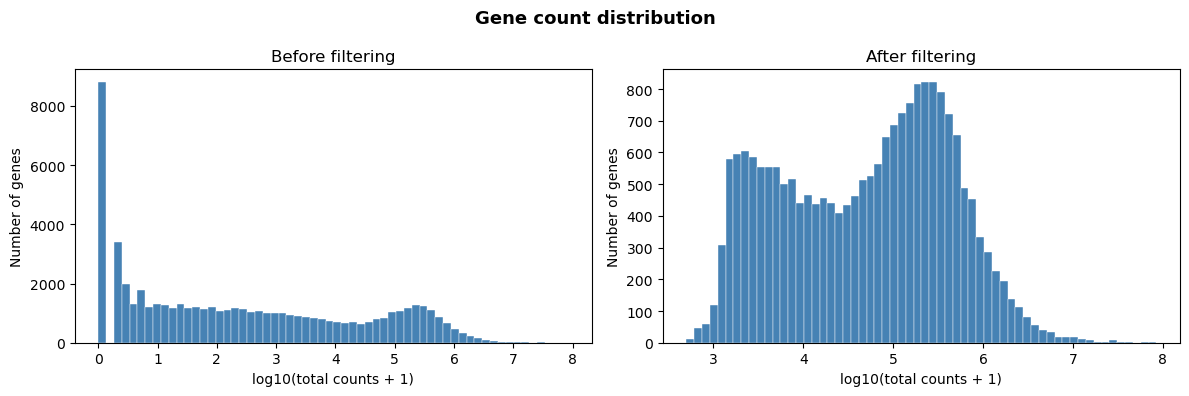

In [7]:
# Visualise the count distribution (log10 total counts per gene)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, title) in zip(
    axes,
    [(counts, "Before filtering"), (counts_filtered, "After filtering")]
):
    total = df.sum(axis=1)
    ax.hist(np.log10(total + 1), bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_xlabel("log10(total counts + 1)")
    ax.set_ylabel("Number of genes")
    ax.set_title(title)

fig.suptitle("Gene count distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(op.join(OUTDIR, "count_distribution.png"), dpi=150)
plt.show()

---
## 3 — Run PyDESeq2

PyDESeq2 implements the **DESeq2** statistical framework in Python. Deseq2 is originally implemented in R for which you will also find a more comprehensive documentation of the statistics.
The workflow has two main objects:

| Object | Purpose |
|--------|---------|
| `DeseqDataSet` | Stores counts + metadata; estimates size factors and dispersions |
| `DeseqStats` | Performs Wald tests and corrects for multiple comparisons |

### Key concepts

- **Size factors** — account for differences in sequencing depth between samples.
- **Dispersion** — models the gene-level variance (biological + technical noise).
- **Wald test** — tests whether the log2 fold change for a given contrast is significantly different from zero.
- **Benjamini–Hochberg (BH) correction** — controls the false discovery rate (FDR).

> **Resources:**
> - https://pydeseq2.readthedocs.io/en/latest/auto_examples/plot_pandas_DESeq2.html
> - https://pydeseq2.readthedocs.io/en/latest/api.html

### 3.1 — Build the `DeseqDataSet`

PyDESeq2 expects the count matrix in **samples × genes** orientation (transposed relative
to the standard bioinformatics convention of genes × samples). 

We make sure that the metadata and the counts are aligned and transpose the data.

Make sure that the index of the pandas data frame is set correctly so DeSeq2 knowns which are the cases and controls.

In [8]:
comparisons = ['case', 'control']

In [9]:
mysamples = counts_filtered.columns[metadata['condition'].isin(comparisons)]
counts_filtered = counts_filtered.loc[:, mysamples]
metadata_filtered = metadata[metadata['sample'].isin(mysamples)]
metadata_filtered= metadata_filtered.set_index('sample')

In [10]:
# PyDESeq2 expects counts as samples × genes (rows = samples)
counts_T = counts_filtered.T  # shape: samples × genes

# Make sure the counts are integer type
counts_T = counts_T.astype(int)


## Create the DESEQ2 object with the correct formula.
Here we test for differences between case and control, however in many cases we add additional metadata in such as sex, age or batch to control for. You can specify the formula as "~condition"

In [11]:

inference = DefaultInference(n_cpus=4)

dds = DeseqDataSet(
    counts=counts_T,
    metadata=metadata_filtered,
    design_factors="condition",
    #design="~condition",   # more complicated designs can be specified by the formula
    refit_cooks=True,
    inference=inference,
)
counts_T.index
print(dds)

AnnData object with n_obs × n_vars = 366 × 20715
    obs: 'condition'
    obsm: 'design_matrix'


In [12]:
dds.X


array([[ 415,    2, 1386, ...,  107,   61,    5],
       [ 542,   11, 1983, ...,   38,   54,    4],
       [  65,    1,  805, ...,   59,    2,    2],
       ...,
       [ 471,   11, 1511, ...,   37,   46,    1],
       [ 372,  108, 1864, ...,   30,   47,    5],
       [ 281,   77,  918, ...,    9,   37,   15]], shape=(366, 20715))

### 3.2 — Fit the Model

`dds.deseq2()` runs the full DESeq2 pipeline:
1. Estimates size factors (median-of-ratios method).
2. Estimates gene-wise dispersions.
3. Shrinks dispersions toward a fitted trend (empirical Bayes).
4. Fits negative binomial GLMs.
5. Refits for samples with high Cook's distance (outlier detection).

In [ ]:
dds.deseq2()
print("Model fitting complete. ✔")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.23 seconds.

Fitting dispersions...
... done in 11.91 seconds.

Fitting dispersion trend curve...
... done in 0.56 seconds.

Fitting MAP dispersions...


### 3.3 — Dispersion Plot

Plotting the per-gene dispersion estimates against their mean counts is a standard
quality-check step. Expect to see:

- High dispersion for low-count genes.
- A downward trend as mean counts increase.
- Final (MAP) estimates shrunk toward the fitted trend (red curve).

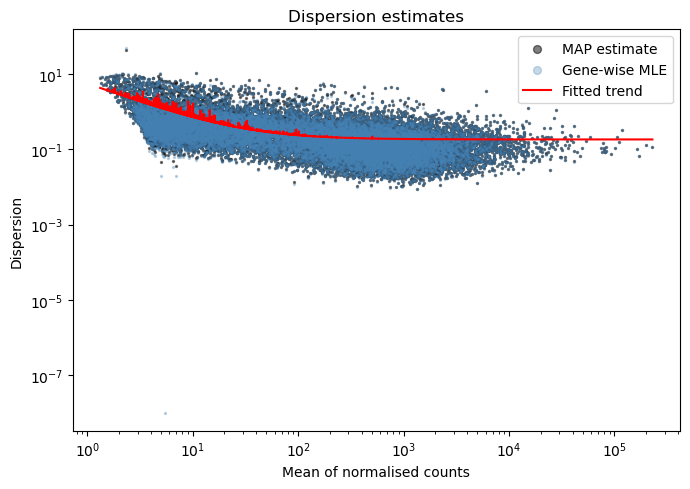

In [ ]:
# Extract dispersion information from the fitted object
mean_counts = dds.layers["normed_counts"].mean(axis=0)   # mean normalised counts per gene
dispersions_gene = dds.var["genewise_dispersions"]       # gene-wise MLEs
dispersions_map  = dds.var["MAP_dispersions"]            # MAP (shrunk) estimates
trend            = dds.var["fitted_dispersions"]         # parametric trend

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mean_counts, dispersions_map,  s=2, alpha=0.5, color="black",     label="MAP estimate")
ax.scatter(mean_counts, dispersions_gene, s=2, alpha=0.3, color="steelblue", label="Gene-wise MLE")

# Sort for a smooth trend line
order = np.argsort(mean_counts)
ax.plot(mean_counts[order], trend[order], color="red", lw=1.5, label="Fitted trend")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Mean of normalised counts")
ax.set_ylabel("Dispersion")
ax.set_title("Dispersion estimates")
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig(op.join(OUTDIR , "dispersion_plot.png"), dpi=150)
plt.show()

### 3.4 — Run Wald Test and Extract Results

Define the **contrast** — which comparison to test.
A contrast is specified as `[factor, numerator_level, denominator_level]`.

For example, `["condition", "treated", "control"]` tests:

$$\log_2\!\left(\frac{\text{treated}}{\text{control}}\right)$$

Positive log2FC → higher expression in the numerator group (treated).  
Negative log2FC → lower expression in the numerator group (treated).

In [ ]:
# Adapt these values to match the levels in your metadata 'condition' column.
CONDITIONS = metadata["condition"].unique().tolist()
print("Available conditions:", CONDITIONS)

# Set numerator and denominator — change these if needed.
NUMERATOR   = 'case'
DENOMINATOR = 'control'

print(f"\nContrast: {NUMERATOR} vs {DENOMINATOR}  "
      f"(positive LFC = higher in '{NUMERATOR}')")

Available conditions: ['control', 'case']

Contrast: case vs control  (positive LFC = higher in 'case')


In [ ]:
stat_res = DeseqStats(
    dds,
    contrast=["condition", NUMERATOR, DENOMINATOR],
    inference=inference
)

stat_res.summary()

results = stat_res.results_df
print(f"\nResult table shape: {results.shape}")
display(results.head(10))

Running Wald tests...


Log2 fold change & Wald test p-value: condition case vs control
                    baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000000003   283.294739       -0.124895  0.039799 -3.138188   
ENSG00000000005    57.005264       -1.071866  0.204316 -5.246111   
ENSG00000000419  1065.339635       -0.017869  0.033675 -0.530630   
ENSG00000000457   280.043597        0.104269  0.032578  3.200565   
ENSG00000000460    67.385424        0.112142  0.044042  2.546262   
...                      ...             ...       ...       ...   
ENSG00000273486    50.950873       -0.016327  0.059589 -0.273993   
ENSG00000273487    30.520069       -0.006588  0.079235 -0.083149   
ENSG00000273489    25.903101        0.184759  0.091277  2.024168   
ENSG00000273492    26.986739       -0.096964  0.090254 -1.074349   
ENSG00000273493     4.031067       -0.008787  0.130142 -0.067516   

                       pvalue      padj  
ENSG00000000003  1.699956e-03  0.007458  
ENSG00000000005  1.553429e-07  0.00

... done in 1.44 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ENSG00000000003,283.294739,-0.124895,0.039799,-3.138188,1.699956e-03,7.457560e-03
ENSG00000000005,57.005264,-1.071866,0.204316,-5.246111,1.553429e-07,3.230852e-06
ENSG00000000419,1065.339635,-0.017869,0.033675,-0.530630,5.956754e-01,7.166579e-01
ENSG00000000457,280.043597,0.104269,0.032578,3.200565,1.371586e-03,6.230912e-03
ENSG00000000460,67.385424,0.112142,0.044042,2.546262,1.088833e-02,3.389717e-02
ENSG00000000938,227.772465,0.134393,0.088009,1.527036,1.267521e-01,2.353805e-01
ENSG00000000971,2725.291061,-0.458635,0.080700,-5.683190,1.322056e-08,3.986374e-07
ENSG00000001036,1196.169614,0.106578,0.030889,3.450360,5.598395e-04,2.962973e-03
ENSG00000001084,830.697978,0.096743,0.051960,1.861857,6.262331e-02,1.363623e-01
ENSG00000001167,330.338997,0.001960,0.070743,0.027701,9.779005e-01,9.861362e-01


In [ ]:
# Quick summary of significance
FDR_THRESHOLD = 0.05
LFC_THRESHOLD = 1.0   # |log2FC| > 1 corresponds to a 2-fold change

sig = results.dropna(subset=["padj"])
sig = sig[(sig["padj"] < FDR_THRESHOLD) & (sig["log2FoldChange"].abs() > LFC_THRESHOLD)]

print(f"Significant DE genes (FDR < {FDR_THRESHOLD}, |LFC| > {LFC_THRESHOLD}): {len(sig):,}")
print(f"  Up-regulated   (in {NUMERATOR}): {(sig['log2FoldChange'] > 0).sum():,}")
print(f"  Down-regulated (in {NUMERATOR}): {(sig['log2FoldChange'] < 0).sum():,}")

Significant DE genes (FDR < 0.05, |LFC| > 1.0): 169
  Up-regulated   (in case): 72
  Down-regulated (in case): 97


---
## 4 — Visualize Results

Three complementary visualizations are standard in DE analyses:

| Plot | X-axis | Y-axis | Purpose |
|------|--------|--------|---------|
| MA plot | Mean expression | log2FC | Assess fold-change vs expression level |
| Volcano plot | log2FC | −log10(p-value) | Highlight significant genes |
| Heatmap | Samples | Top DE genes | Show expression patterns across samples |

### 4.1 — MA Plot

An MA plot shows the **relationship between mean expression and fold change**.
Ideally, most genes should cluster around LFC = 0 (no change), with DE genes
scattered above/below.

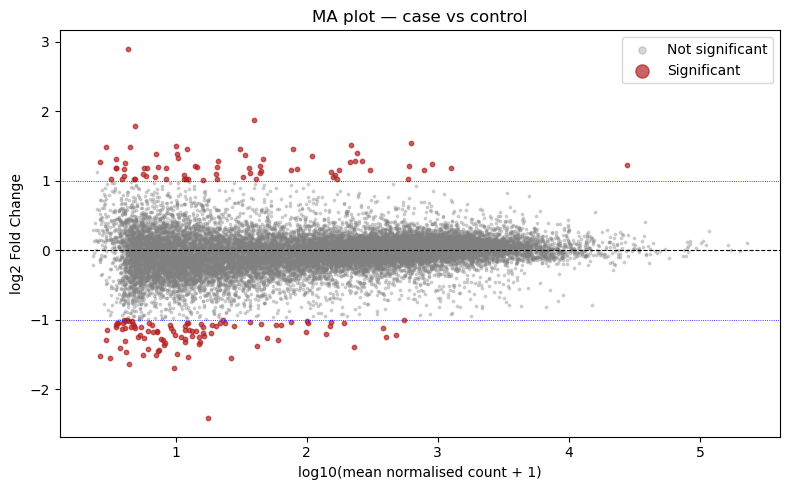

In [ ]:
df_ma = results.dropna(subset=["padj", "log2FoldChange", "baseMean"]).copy()
df_ma["significant"] = (df_ma["padj"] < FDR_THRESHOLD) & (df_ma["log2FoldChange"].abs() > LFC_THRESHOLD)

fig, ax = plt.subplots(figsize=(8, 5))

# Non-significant genes
ns = df_ma[~df_ma["significant"]]
ax.scatter(np.log10(ns["baseMean"] + 1), ns["log2FoldChange"],
           s=3, alpha=0.3, color="grey", label="Not significant", rasterized=True)

# Significant genes
s = df_ma[df_ma["significant"]]
ax.scatter(np.log10(s["baseMean"] + 1), s["log2FoldChange"],
           s=10, alpha=0.7, color="firebrick", label="Significant", rasterized=True)

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axhline( LFC_THRESHOLD, color="blue", lw=0.6, ls=":")
ax.axhline(-LFC_THRESHOLD, color="blue", lw=0.6, ls=":")
ax.set_xlabel("log10(mean normalised count + 1)")
ax.set_ylabel("log2 Fold Change")
ax.set_title(f"MA plot — {NUMERATOR} vs {DENOMINATOR}")
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(op.join(OUTDIR, "ma_plot.png"), dpi=150)
plt.show()

### 4.2 — Volcano Plot

A volcano plot maps **fold change** against **statistical significance**, making it easy
to spot genes that are both highly significant and strongly changed.

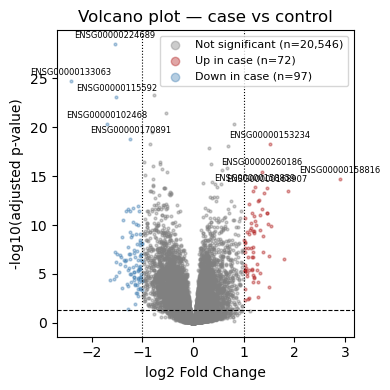

In [ ]:
df_vol = results.dropna(subset=["padj", "log2FoldChange", "pvalue"]).copy()
df_vol["-log10padj"] = -np.log10(df_vol["padj"].clip(lower=1e-300))
df_vol["significant"] = (df_vol["padj"] < FDR_THRESHOLD) & (df_vol["log2FoldChange"].abs() > LFC_THRESHOLD)

# Color categories
def _color(row):
    if not row["significant"]:
        return "grey"
    return "firebrick" if row["log2FoldChange"] > 0 else "steelblue"

df_vol["color"] = df_vol.apply(_color, axis=1)

fig, ax = plt.subplots(figsize=(4, 4))

for color, label in [("grey", "Not significant"),
                     ("firebrick", f"Up in {NUMERATOR}"),
                     ("steelblue", f"Down in {NUMERATOR}")]:
    subset = df_vol[df_vol["color"] == color]
    ax.scatter(subset["log2FoldChange"], subset["-log10padj"],
               s=4, alpha=0.4, color=color, label=f"{label} (n={len(subset):,})",
               rasterized=True)

# Threshold lines
ax.axhline(-np.log10(FDR_THRESHOLD), color="black", lw=0.8, ls="--")
ax.axvline( LFC_THRESHOLD, color="black", lw=0.8, ls=":")
ax.axvline(-LFC_THRESHOLD, color="black", lw=0.8, ls=":")

# Label top genes by adjusted p-value
top_genes = df_vol[df_vol["significant"]].nsmallest(10, "padj")
for gene, row in top_genes.iterrows():
    ax.annotate(gene, (row["log2FoldChange"], row["-log10padj"]),
                fontsize=6, ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points")

ax.set_xlabel("log2 Fold Change")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title(f"Volcano plot — {NUMERATOR} vs {DENOMINATOR}")
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.savefig(op.join(OUTDIR , "volcano_plot.png"), dpi=150)
plt.show()

### 4.3 — Heatmap of Top DE Genes

Visualise the variance-stabilised expression of the top DE genes across samples to
confirm that the groups separate as expected.

PyDESeq2 provides **variance-stabilising transformation (VST)** via
`dds.vst_fit()` / `dds.vst_transform()`, which brings counts onto a roughly
homoscedastic log-scale suitable for heatmaps and PCA.

The heatmap groups similar genes and samples together in a hierarchical clustering, allowing us to verify if the differntially expressed gene allow us to find the groups (case and control) again in a clustering. The higher the aggreement between the clustering and the original labels, the more specific the genes are to the condition.

In [ ]:
# To get human readable gene names, we have downloaded the biomart mapping between ensembl IDs and gene names.
# We create a mapping, and add the human-readable gene name as a column to the results.
biomart = pd.read_csv('../data/biomart.txt', sep = '\t')
gene_mapper = dict(zip(biomart['Gene stable ID'], biomart['Gene name']))
results['gene_name'] = results.index.map(gene_mapper)

Plotting heatmap for top 100 DE genes.


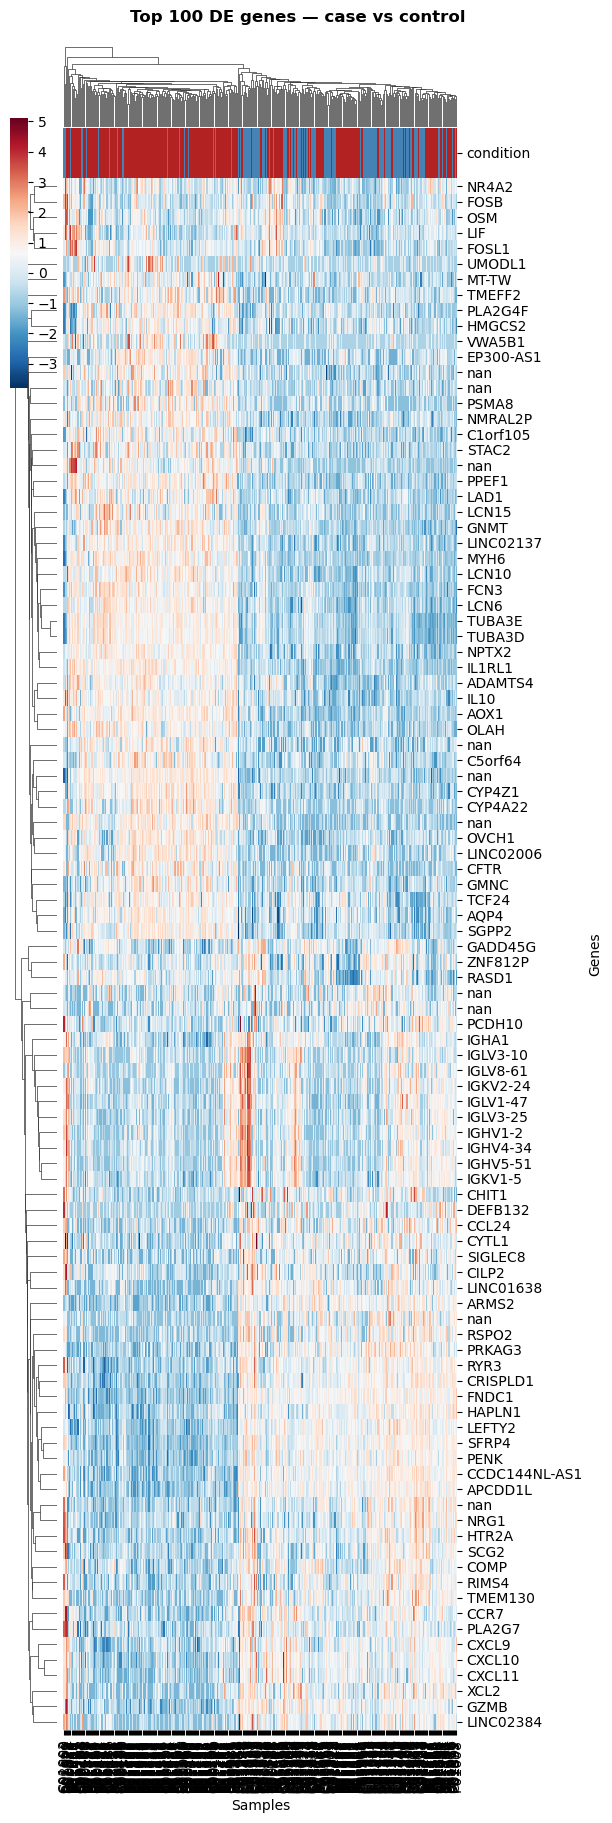

In [ ]:
# Select top N significant genes (by adjusted p-value)
TOP_N = 100
top_de_genes = (
    results.dropna(subset=["padj"])
    .query("padj < @FDR_THRESHOLD and log2FoldChange.abs() > @LFC_THRESHOLD")
    .nsmallest(TOP_N, "padj")
    .index.tolist()
)

if not top_de_genes:
    print("No significant DE genes found — skipping heatmap.")
else:
    print(f"Plotting heatmap for top {len(top_de_genes)} DE genes.")

    # Use log-normalised counts (log1p of size-factor-normalised counts)
    normed = pd.DataFrame(
        dds.layers["normed_counts"],
        index=dds.obs_names,
        columns=dds.var_names,
    )
    log_normed = np.log1p(normed)

    heatmap_data = log_normed[top_de_genes].T   # genes × samples

    # Annotate columns with condition
    col_colors = metadata_filtered["condition"].map(
        {NUMERATOR: "firebrick", DENOMINATOR: "steelblue"}
    )

    heatmap_data.index = heatmap_data.index.map(gene_mapper)
    g = sns.clustermap(
        heatmap_data,
        col_colors=col_colors,
        z_score=0,              # Z-score per gene (row)
        cmap="RdBu_r",
        figsize=(6, max(10, TOP_N * 0.18)),
        xticklabels=True,
        yticklabels=True,
        linewidths=0,
        dendrogram_ratio=(0.1, 0.05),
        cbar_pos=(0.02, 0.8, 0.03, 0.15),
    )
    g.ax_heatmap.set_xlabel("Samples")
    g.ax_heatmap.set_ylabel("Genes")
    g.fig.suptitle(f"Top {TOP_N} DE genes — {NUMERATOR} vs {DENOMINATOR}",
                   y=1.01, fontsize=12, fontweight="bold")
    g.savefig(op.join(OUTDIR ,"heatmap_top_de_genes.png"), dpi=150, bbox_inches="tight")
    plt.show()